# Hand Osteoporosis Dataset — Extensive EDA

This notebook provides a comprehensive exploratory data analysis of the dataset in the `data/` folder, which contains:
- **`hand.xlsx`** — 3 590 patient rows × 275 columns of hand X-ray radiographic scores across two visit timepoints (v00 baseline, v06 follow-up)
- **`Finger Joints.zip`** — 41 060 cropped finger-joint PNG images for 3 556 patients across 12 joint types

**Score types**
| Suffix | Meaning |
|--------|---------|
| `_KL` | Kellgren-Lawrence grade (0–4) |
| `_OP` | Osteophytes (0–3) |
| `_JSN` | Joint Space Narrowing (0–3) |
| `_PW` | Periarticular Width |
| `_ER` | Erosion |
| `_ME` | Malalignment/Erosion |
| `_CY` | Cysts |

**Joint abbreviations:** DIP2-5, IP1, PIP2-5, MCP1-5, CMC1, STT

## 0 · Setup

In [3]:
import re
import zipfile
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

DATA_DIR  = Path('../data')
XLSX_PATH = DATA_DIR / 'hand.xlsx'
ZIP_PATH  = DATA_DIR / 'Finger Joints.zip'

print('Libraries loaded.')

Libraries loaded.


## 1 · Load the tabular data

In [4]:
df = pd.read_excel(XLSX_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (3590, 275)


,duryeaid,v00DIP2_KL,v00DIP3_KL,v00DIP4_KL,v00DIP5_KL,v00IP1_KL,v00PIP2_KL,v00PIP3_KL,v00PIP4_KL,v00PIP5_KL,...,v06KLReview_CY,v06MEReview_CY,v06FlagOther_CY,id,v00hand,v00Folder,v06hand,v06Folder,v00Folder2,v06Folder2
0,15937,0,1.0,1.0,1.0,2.0,0,0.0,1.0,1.0,...,0,0,NaN,9000099,0,0.E.1/9000099/20050708/00877806,0,6.E.1/9000099/20090728/03279103,"xcopy ""D:/0.E.1/9000099/20050708/00877806"" ""C:...","xcopy ""D:/6.E.1/9000099/20090728/03279103"" ""C:..."
1,17642,2,2.0,2.0,1.0,1.0,1,2.0,0.0,2.0,...,0,0,NaN,9000296,0,0.C.2/9000296/20040909/00287404,0,6.C.1/9000296/20080808/02747203,"xcopy ""D:/0.C.2/9000296/20040909/00287404"" ""C:...","xcopy ""D:/6.C.1/9000296/20080808/02747203"" ""C:..."
2,17546,0,2.0,0.0,2.0,1.0,0,2.0,1.0,1.0,...,0,0,NaN,9000798,0,0.C.2/9000798/20040924/00270504,0,6.C.1/9000798/20081107/02891503,"xcopy ""D:/0.C.2/9000798/20040924/00270504"" ""C:...","xcopy ""D:/6.C.1/9000798/20081107/02891503"" ""C:..."


## 2 · Column taxonomy

In [5]:
# Parse column names into structured metadata
SCORE_TYPES = ['KL', 'OP', 'JSN', 'PW', 'ER', 'ME', 'CY']
VISITS      = ['v00', 'v06']

pattern = re.compile(r'^(v00|v06)(\w+)_(KL|OP|JSN|PW|ER|ME|CY)$')
score_cols = []
for c in df.columns:
    m = pattern.match(c)
    if m:
        score_cols.append({'col': c, 'visit': m.group(1), 'joint': m.group(2), 'score_type': m.group(3)})

meta = pd.DataFrame(score_cols)
print(f'Score columns: {len(meta)}')
print(f"Visits: {meta['visit'].unique()}")
print(f"Joints: {sorted(meta['joint'].unique())}")
print(f"Score types: {meta['score_type'].unique()}")
meta.head(10)

Score columns: 266
Visits: <StringArray>
['v00', 'v06']
Length: 2, dtype: str
Joints: ['CMC1', 'DIP2', 'DIP3', 'DIP4', 'DIP5', 'FlagOther', 'IP1', 'KLReview', 'MCP1', 'MCP2', 'MCP3', 'MCP4', 'MCP5', 'MEReview', 'PIP2', 'PIP3', 'PIP4', 'PIP5', 'STT']
Score types: <StringArray>
['KL', 'OP', 'JSN', 'PW', 'ER', 'ME', 'CY']
Length: 7, dtype: str


,col,visit,joint,score_type
0,v00DIP2_KL,v00,DIP2,KL
1,v00DIP3_KL,v00,DIP3,KL
2,v00DIP4_KL,v00,DIP4,KL
3,v00DIP5_KL,v00,DIP5,KL
4,v00IP1_KL,v00,IP1,KL
5,v00PIP2_KL,v00,PIP2,KL
6,v00PIP3_KL,v00,PIP3,KL
7,v00PIP4_KL,v00,PIP4,KL
8,v00PIP5_KL,v00,PIP5,KL
9,v00MCP1_KL,v00,MCP1,KL


## 3 · Basic statistics

In [6]:
score_df = df[meta['col'].tolist()]
print('Numeric summary of all score columns:')
score_df.describe().T.sort_values('mean', ascending=False).head(30)

Numeric summary of all score columns:


,count,mean,std,min,25%,50%,75%,max
v00FlagOther_KL,6.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
v06FlagOther_KL,8.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
v06CMC1_KL,3565.0,0.984292,1.138195,0.0,0.0,1.0,2.0,4.0
v06DIP2_KL,3590.0,0.964345,1.109677,0.0,0.0,0.0,2.0,4.0
v00DIP2_KL,3590.0,0.894150,1.072176,0.0,0.0,0.0,2.0,4.0
v06DIP5_KL,3583.0,0.893665,1.054422,0.0,0.0,0.0,2.0,4.0
v00CMC1_KL,3574.0,0.879127,1.054329,0.0,0.0,0.0,2.0,4.0
v00DIP5_KL,3574.0,0.848629,1.024621,0.0,0.0,0.0,2.0,4.0
v06STT_KL,3563.0,0.802694,1.010375,0.0,0.0,0.0,2.0,4.0
v06IP1_KL,3588.0,0.770346,0.997175,0.0,0.0,0.0,2.0,4.0


## 4 · Missing value analysis

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
miss_df = miss_df[miss_df['missing'] > 0]
print(f'Columns with missing values: {len(miss_df)}')

# Separate FlagOther (always missing) from real missingness
flag_cols = miss_df[miss_df['pct'] == 100]
real_miss  = miss_df[miss_df['pct'] < 100]
print(f'Entirely empty (FlagOther) cols: {len(flag_cols)}')
print(f'Partially missing cols: {len(real_miss)}')
real_miss

Columns with missing values: 188
Entirely empty (FlagOther) cols: 12
Partially missing cols: 176


,missing,pct
v00FlagOther_KL,3584,99.83
v06FlagOther_KL,3582,99.78
v06STT_OP,30,0.84
v06STT_JSN,29,0.81
v06STT_KL,27,0.75
...,...,...
v00MCP4_ER,1,0.03
v00MCP3_ER,1,0.03
v00DIP3_OP,1,0.03
v06MCP4_ER,1,0.03


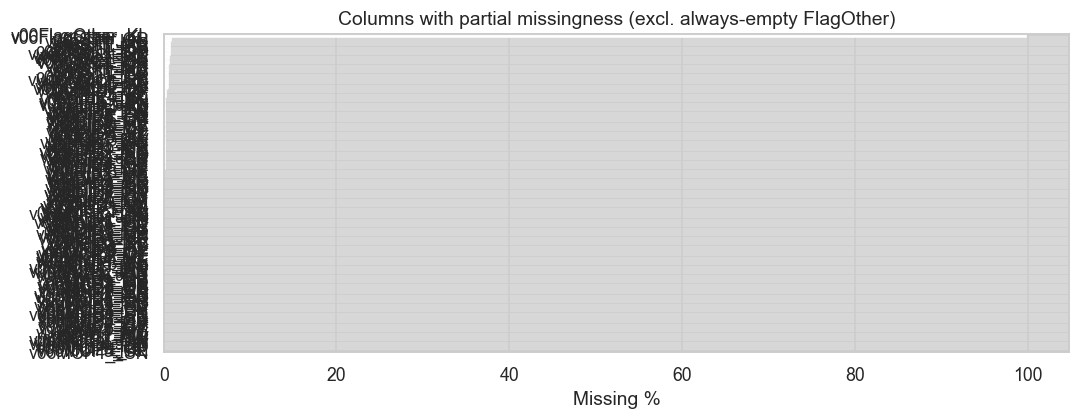

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
real_miss['pct'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing %')
ax.set_title('Columns with partial missingness (excl. always-empty FlagOther)')
plt.tight_layout()
plt.show()

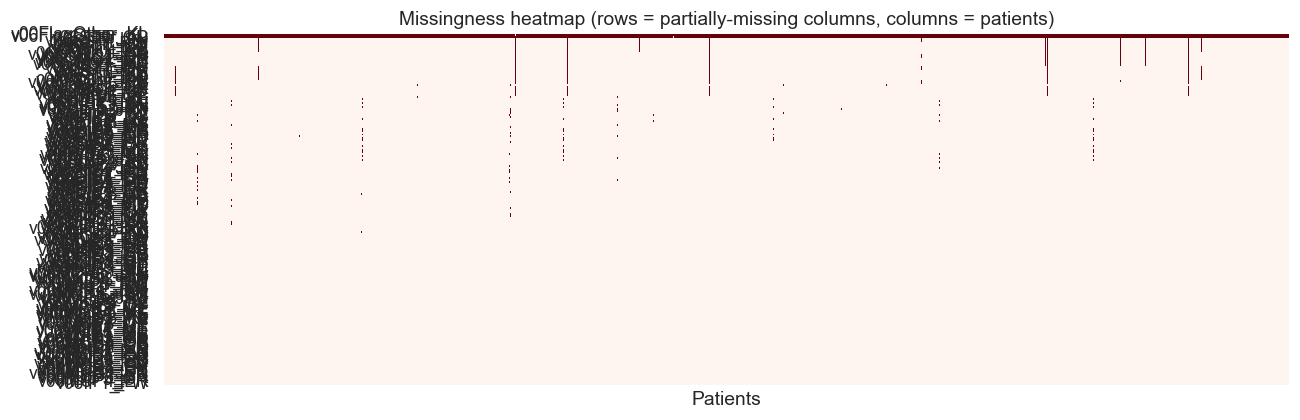

In [9]:
# Missingness heatmap per patient (row)
real_miss_cols = real_miss.index.tolist()
miss_matrix = df[real_miss_cols].isnull().astype(int)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(miss_matrix.T, ax=ax, cbar=False, xticklabels=False, yticklabels=True, cmap='Reds')
ax.set_title('Missingness heatmap (rows = partially-missing columns, columns = patients)')
ax.set_xlabel('Patients')
plt.tight_layout()
plt.show()

## 5 · Hand laterality

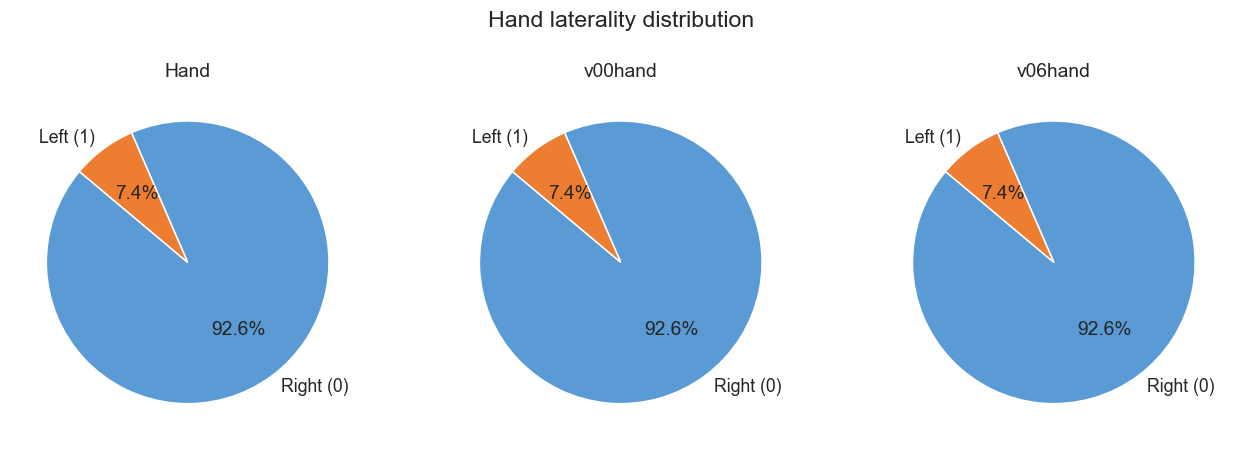

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ['Hand', 'v00hand', 'v06hand']):
    counts = df[col].value_counts().sort_index()
    labels = {0: 'Right (0)', 1: 'Left (1)'}
    ax.pie(counts, labels=[labels.get(i, str(i)) for i in counts.index],
           autopct='%1.1f%%', startangle=140, colors=['#5B9BD5', '#ED7D31'])
    ax.set_title(col)
plt.suptitle('Hand laterality distribution', y=1.02)
plt.tight_layout()
plt.show()

## 6 · Score-type distributions (v00 baseline)

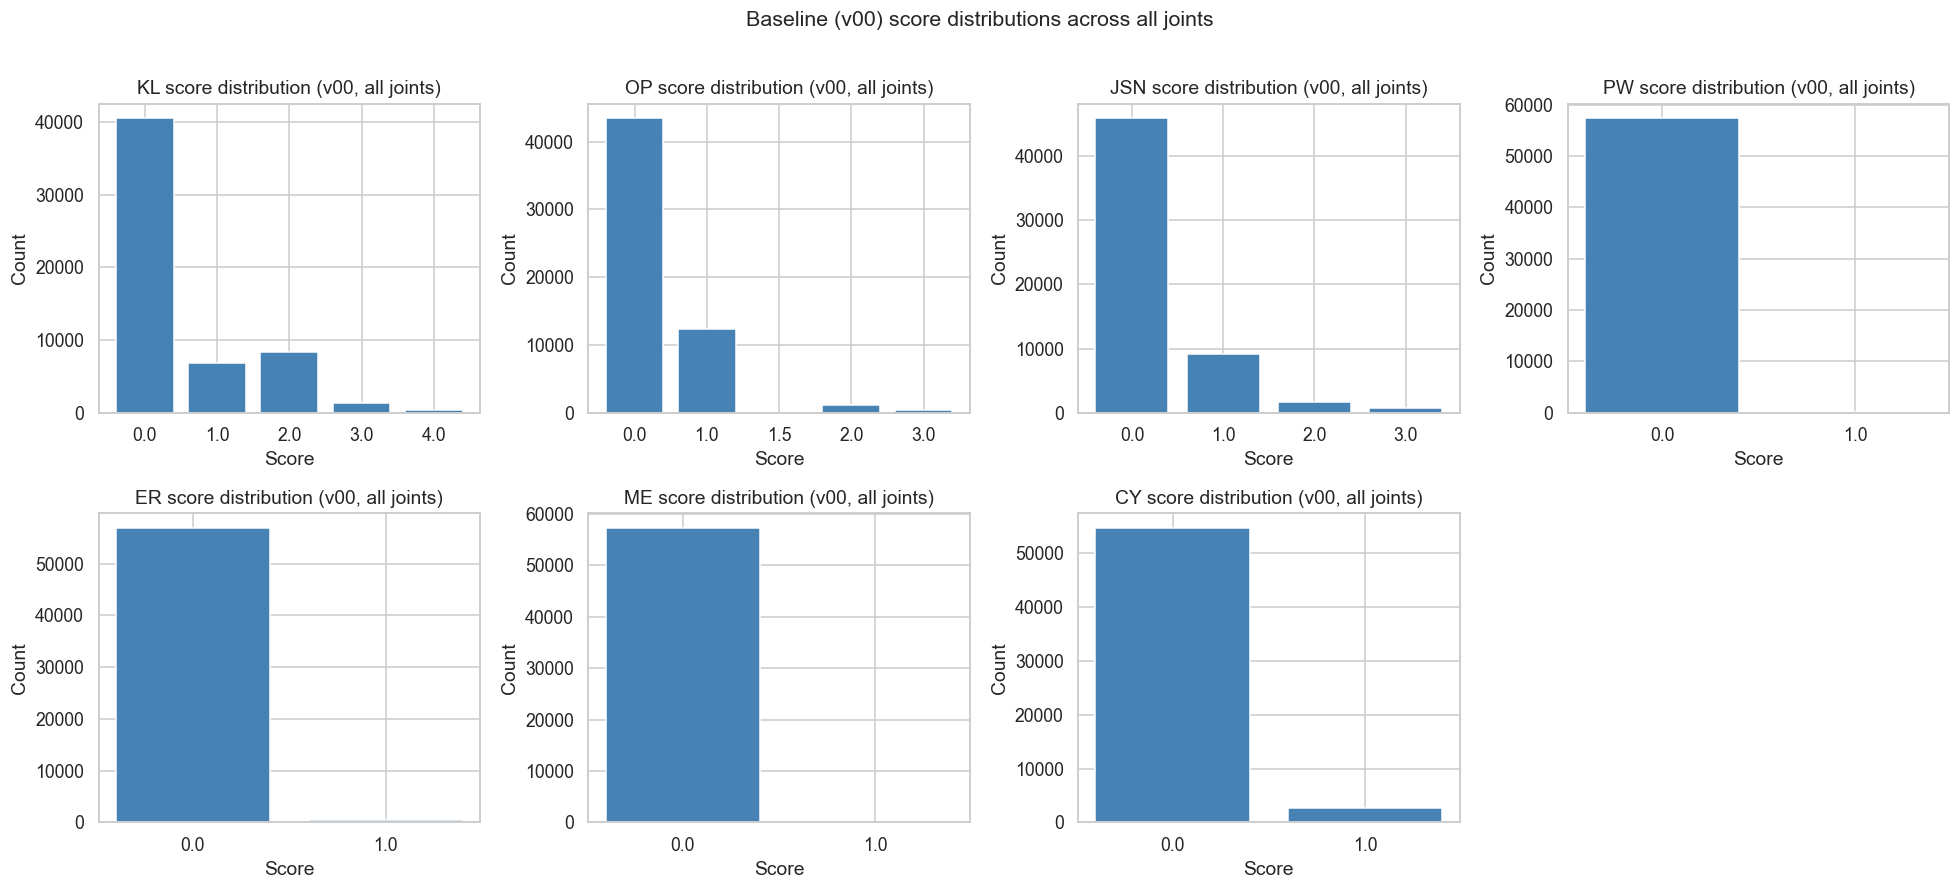

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, st in enumerate(SCORE_TYPES):
    cols = meta[(meta['visit'] == 'v00') & (meta['score_type'] == st) 
                & (~meta['joint'].str.contains('Review|FlagOther'))]['col'].tolist()
    melted = df[cols].melt(var_name='joint_col', value_name='score')
    melted = melted.dropna()
    
    val_counts = melted['score'].value_counts().sort_index()
    axes[idx].bar(val_counts.index.astype(str), val_counts.values, color='steelblue', edgecolor='white')
    axes[idx].set_title(f'{st} score distribution (v00, all joints)')
    axes[idx].set_xlabel('Score')
    axes[idx].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Baseline (v00) score distributions across all joints', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7 · KL grade: joint-level distributions

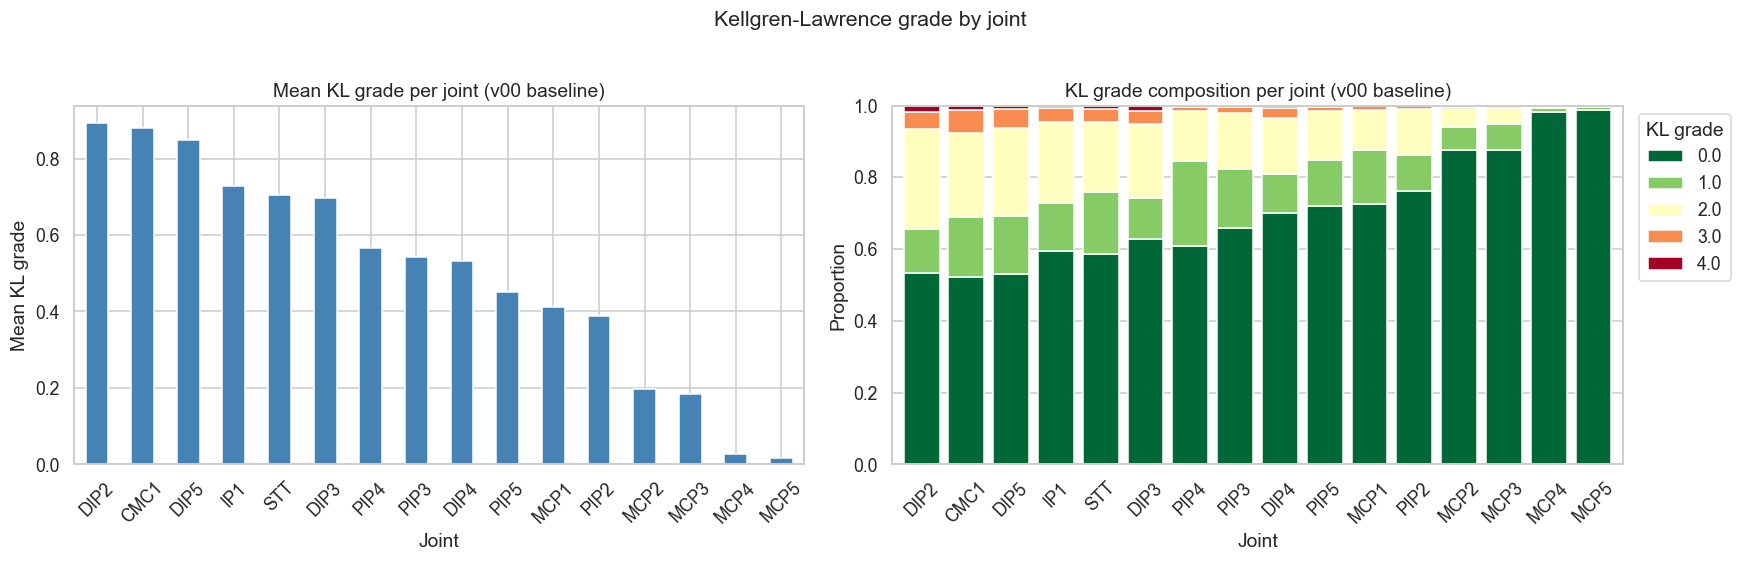

In [12]:
kl_joints = [j for j in sorted(meta['joint'].unique()) if 'Review' not in j and 'FlagOther' not in j]

kl_v00_cols = [f'v00{j}_KL' for j in kl_joints if f'v00{j}_KL' in df.columns]
kl_v00 = df[kl_v00_cols].copy()
kl_v00.columns = [c.replace('v00', '').replace('_KL', '') for c in kl_v00.columns]

# Mean KL per joint
mean_kl = kl_v00.mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mean_kl.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Mean KL grade per joint (v00 baseline)')
axes[0].set_ylabel('Mean KL grade')
axes[0].set_xlabel('Joint')
axes[0].tick_params(axis='x', rotation=45)

# Stacked bar — proportion of each KL grade per joint
kl_props = pd.DataFrame()
for col in kl_v00.columns:
    vc = kl_v00[col].value_counts(normalize=True).sort_index()
    kl_props[col] = vc
kl_props = kl_props.fillna(0).T
kl_props = kl_props.reindex(mean_kl.index)  # same order

kl_props.plot(kind='bar', stacked=True, ax=axes[1],
              colormap='RdYlGn_r', edgecolor='white', width=0.8)
axes[1].set_title('KL grade composition per joint (v00 baseline)')
axes[1].set_ylabel('Proportion')
axes[1].set_xlabel('Joint')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='KL grade', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Kellgren-Lawrence grade by joint', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8 · v00 vs v06 disease progression

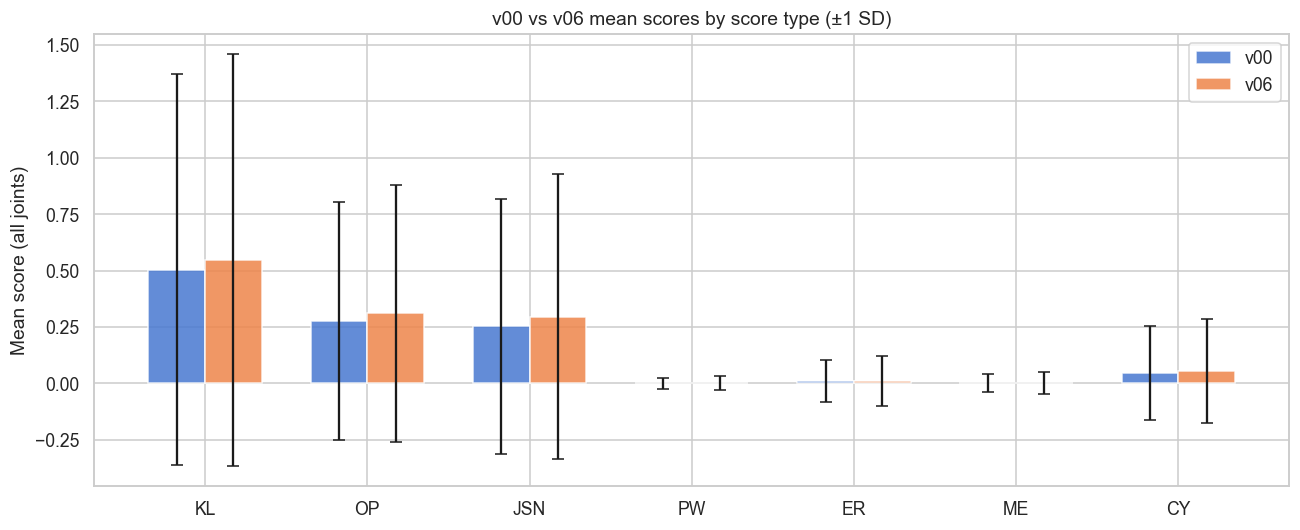

In [13]:
# For each score type, compare mean across all joints between the two visits
progression_rows = []
for st in SCORE_TYPES:
    for visit in VISITS:
        cols = meta[(meta['visit'] == visit) & (meta['score_type'] == st)
                    & (~meta['joint'].str.contains('Review|FlagOther'))]['col'].tolist()
        vals = df[cols].values.flatten()
        vals = vals[~np.isnan(vals)]
        progression_rows.append({'score_type': st, 'visit': visit, 'mean': vals.mean(), 'std': vals.std()})

prog_df = pd.DataFrame(progression_rows)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(SCORE_TYPES))
width = 0.35

for i, visit in enumerate(VISITS):
    sub = prog_df[prog_df['visit'] == visit].set_index('score_type').reindex(SCORE_TYPES)
    ax.bar(x + i * width, sub['mean'], width, yerr=sub['std'], capsize=4,
           label=visit, alpha=0.85)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(SCORE_TYPES)
ax.set_ylabel('Mean score (all joints)')
ax.set_title('v00 vs v06 mean scores by score type (±1 SD)')
ax.legend()
plt.tight_layout()
plt.show()

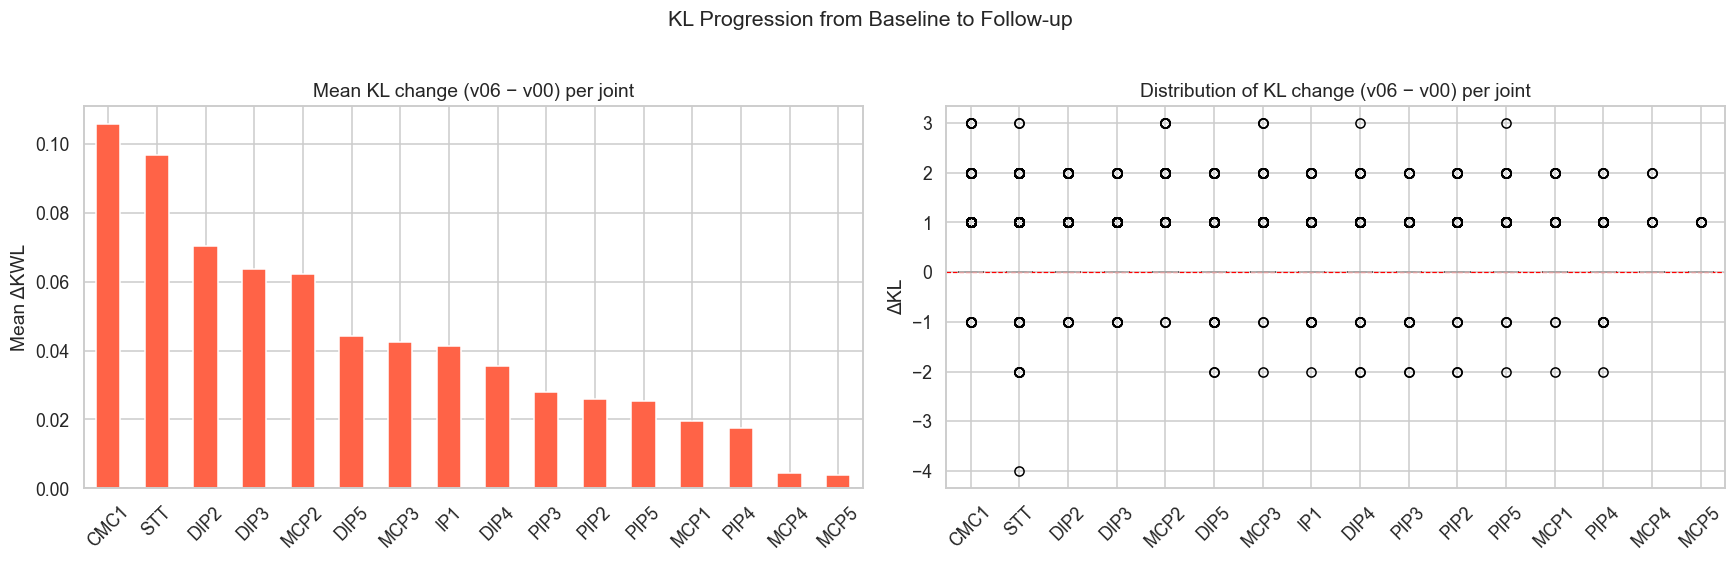

In [14]:
# KL progression per joint: paired delta (v06 - v00)
delta_rows = {}
for j in kl_joints:
    c00 = f'v00{j}_KL'
    c06 = f'v06{j}_KL'
    if c00 in df.columns and c06 in df.columns:
        delta_rows[j] = (df[c06] - df[c00]).dropna()

delta_df = pd.DataFrame(delta_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

delta_mean = delta_df.mean().sort_values(ascending=False)
delta_mean.plot(kind='bar', ax=axes[0], color=['tomato' if v > 0 else 'seagreen' for v in delta_mean], edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Mean KL change (v06 − v00) per joint')
axes[0].set_ylabel('Mean ΔKWL')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot of KL deltas
delta_df[delta_mean.index].boxplot(ax=axes[1], rot=45)
axes[1].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[1].set_title('Distribution of KL change (v06 − v00) per joint')
axes[1].set_ylabel('ΔKL')

plt.suptitle('KL Progression from Baseline to Follow-up', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

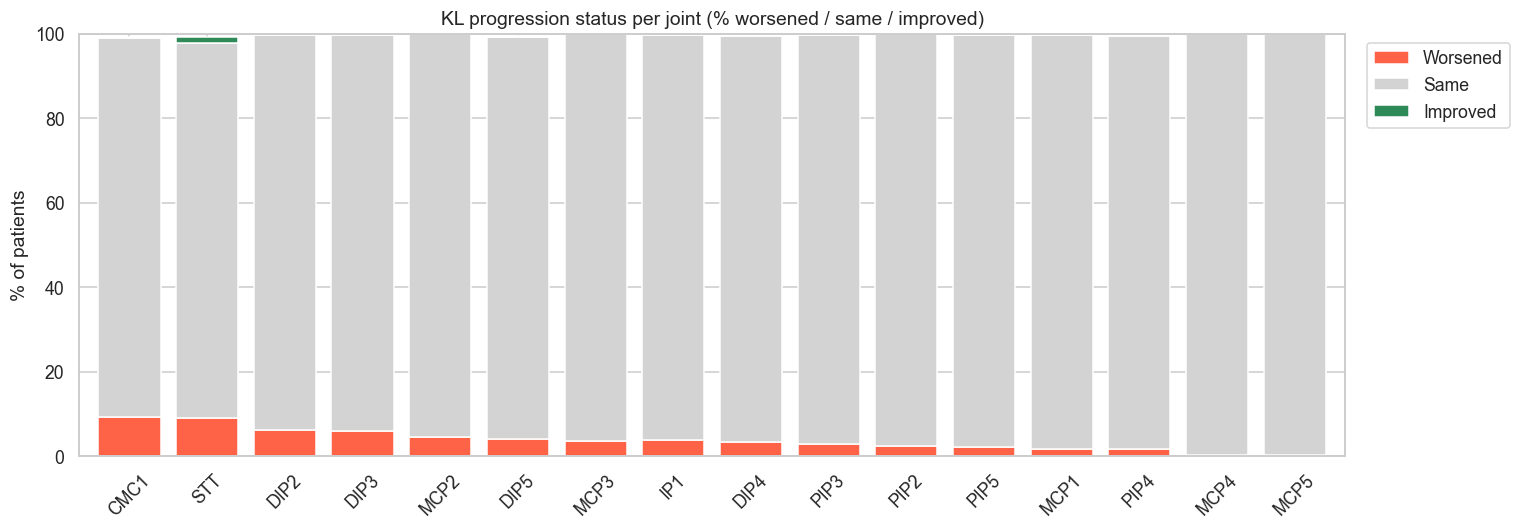

In [15]:
# Proportion of patients who worsened, stayed same, improved per joint
worsened = (delta_df > 0).mean() * 100
same     = (delta_df == 0).mean() * 100
improved = (delta_df < 0).mean() * 100

prog_status = pd.DataFrame({'Worsened': worsened, 'Same': same, 'Improved': improved})
prog_status = prog_status.reindex(delta_mean.index)

fig, ax = plt.subplots(figsize=(14, 5))
prog_status.plot(kind='bar', stacked=True, ax=ax,
                 color=['tomato', 'lightgray', 'seagreen'], edgecolor='white', width=0.8)
ax.set_ylabel('% of patients')
ax.set_title('KL progression status per joint (% worsened / same / improved)')
ax.tick_params(axis='x', rotation=45)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 9 · Per-patient total burden

C:\Users\shinu\AppData\Local\Temp\ipykernel_17188\3480894482.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['kl_sum_v00'] = df[kl_v00_cols_full].sum(axis=1, skipna=True)
C:\Users\shinu\AppData\Local\Temp\ipykernel_17188\3480894482.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['kl_sum_v06'] = df[kl_v06_cols_full].sum(axis=1, skipna=True)
C:\Users\shinu\AppData\Local\Temp\ipykernel_17188\3480894482.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many 

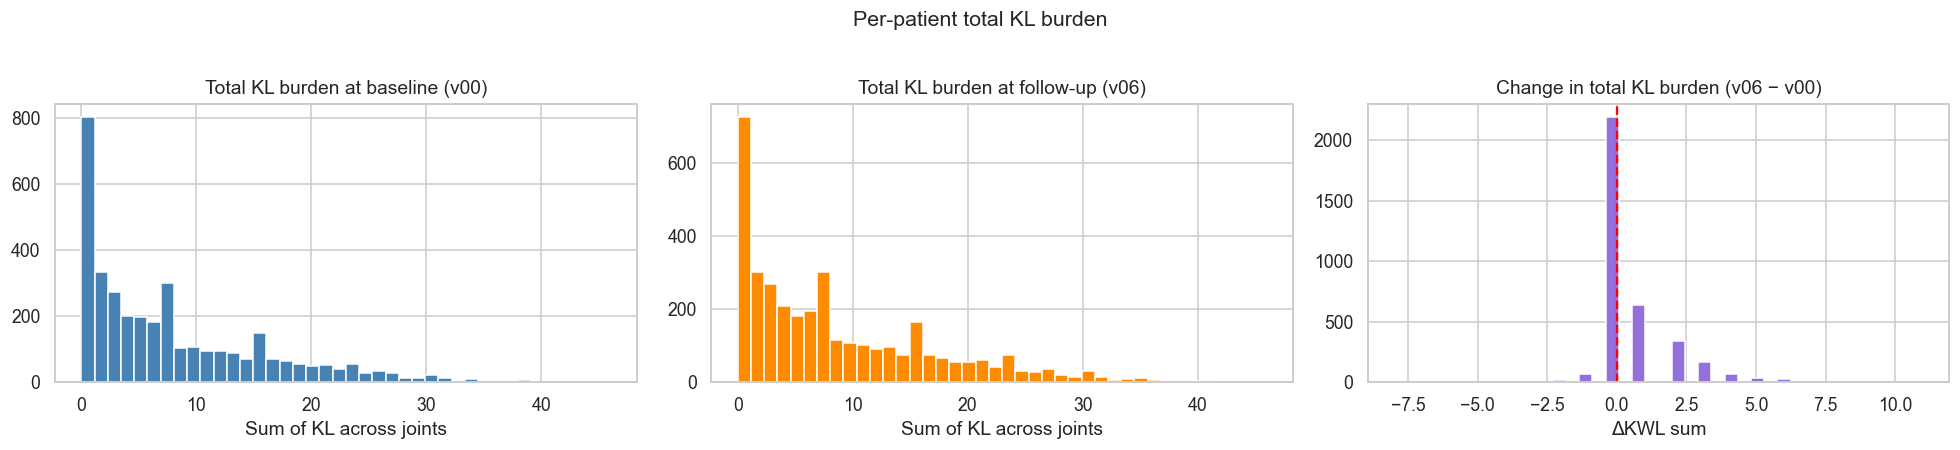

        kl_sum_v00   kl_sum_v06  kl_sum_delta
count  3590.000000  3590.000000   3590.000000
mean      8.050696     8.731755      0.681058
std       8.041457     8.443190      1.311565
min       0.000000     0.000000     -8.000000
25%       2.000000     2.000000      0.000000
50%       5.000000     6.000000      0.000000
75%      12.000000    13.000000      1.000000
max      46.000000    46.000000     11.000000


In [16]:
# Compute per-patient sum of KL scores across all joints at each visit
kl_v00_cols_full = [f'v00{j}_KL' for j in kl_joints if f'v00{j}_KL' in df.columns]
kl_v06_cols_full = [f'v06{j}_KL' for j in kl_joints if f'v06{j}_KL' in df.columns]

df['kl_sum_v00'] = df[kl_v00_cols_full].sum(axis=1, skipna=True)
df['kl_sum_v06'] = df[kl_v06_cols_full].sum(axis=1, skipna=True)
df['kl_sum_delta'] = df['kl_sum_v06'] - df['kl_sum_v00']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df['kl_sum_v00'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Total KL burden at baseline (v00)')
axes[0].set_xlabel('Sum of KL across joints')

axes[1].hist(df['kl_sum_v06'].dropna(), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Total KL burden at follow-up (v06)')
axes[1].set_xlabel('Sum of KL across joints')

axes[2].hist(df['kl_sum_delta'].dropna(), bins=40, color='mediumpurple', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_title('Change in total KL burden (v06 − v00)')
axes[2].set_xlabel('ΔKWL sum')

plt.suptitle('Per-patient total KL burden', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(df[['kl_sum_v00', 'kl_sum_v06', 'kl_sum_delta']].describe())

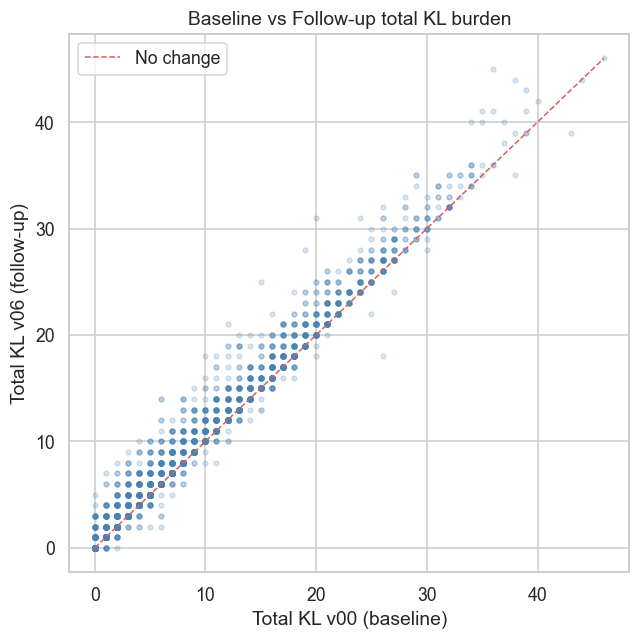

In [17]:
# Scatter: baseline vs follow-up total KL
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df['kl_sum_v00'], df['kl_sum_v06'], alpha=0.2, s=10, color='steelblue')
lims = [0, max(df['kl_sum_v00'].max(), df['kl_sum_v06'].max())]
ax.plot(lims, lims, 'r--', linewidth=1, label='No change')
ax.set_xlabel('Total KL v00 (baseline)')
ax.set_ylabel('Total KL v06 (follow-up)')
ax.set_title('Baseline vs Follow-up total KL burden')
ax.legend()
plt.tight_layout()
plt.show()

## 10 · Correlation analysis

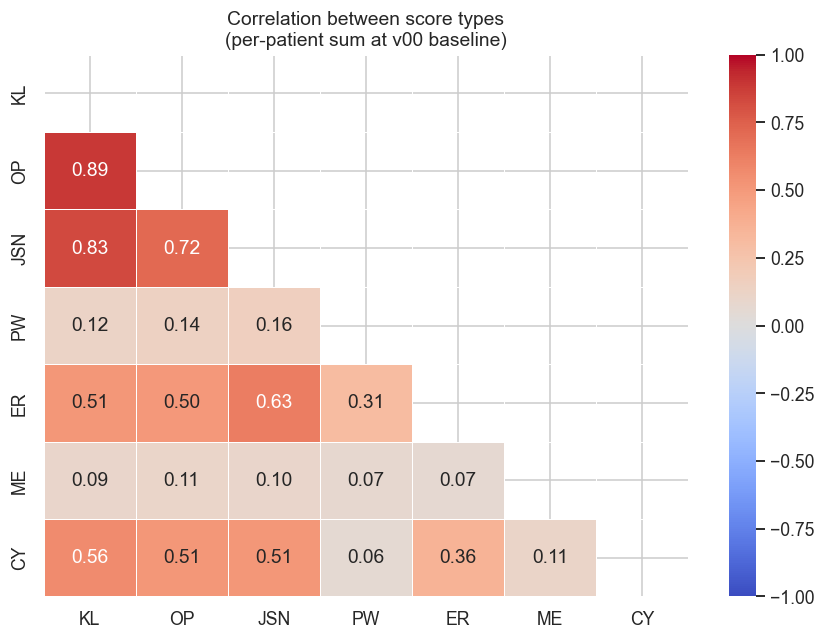

In [18]:
# Correlation between score types at v00 (summed across joints per patient)
sum_cols = {}
for st in SCORE_TYPES:
    cols = meta[(meta['visit'] == 'v00') & (meta['score_type'] == st)
                & (~meta['joint'].str.contains('Review|FlagOther'))]['col'].tolist()
    if cols:
        sum_cols[st] = df[cols].sum(axis=1, skipna=True)

sum_df = pd.DataFrame(sum_cols)
corr = sum_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Correlation between score types\n(per-patient sum at v00 baseline)')
plt.tight_layout()
plt.show()

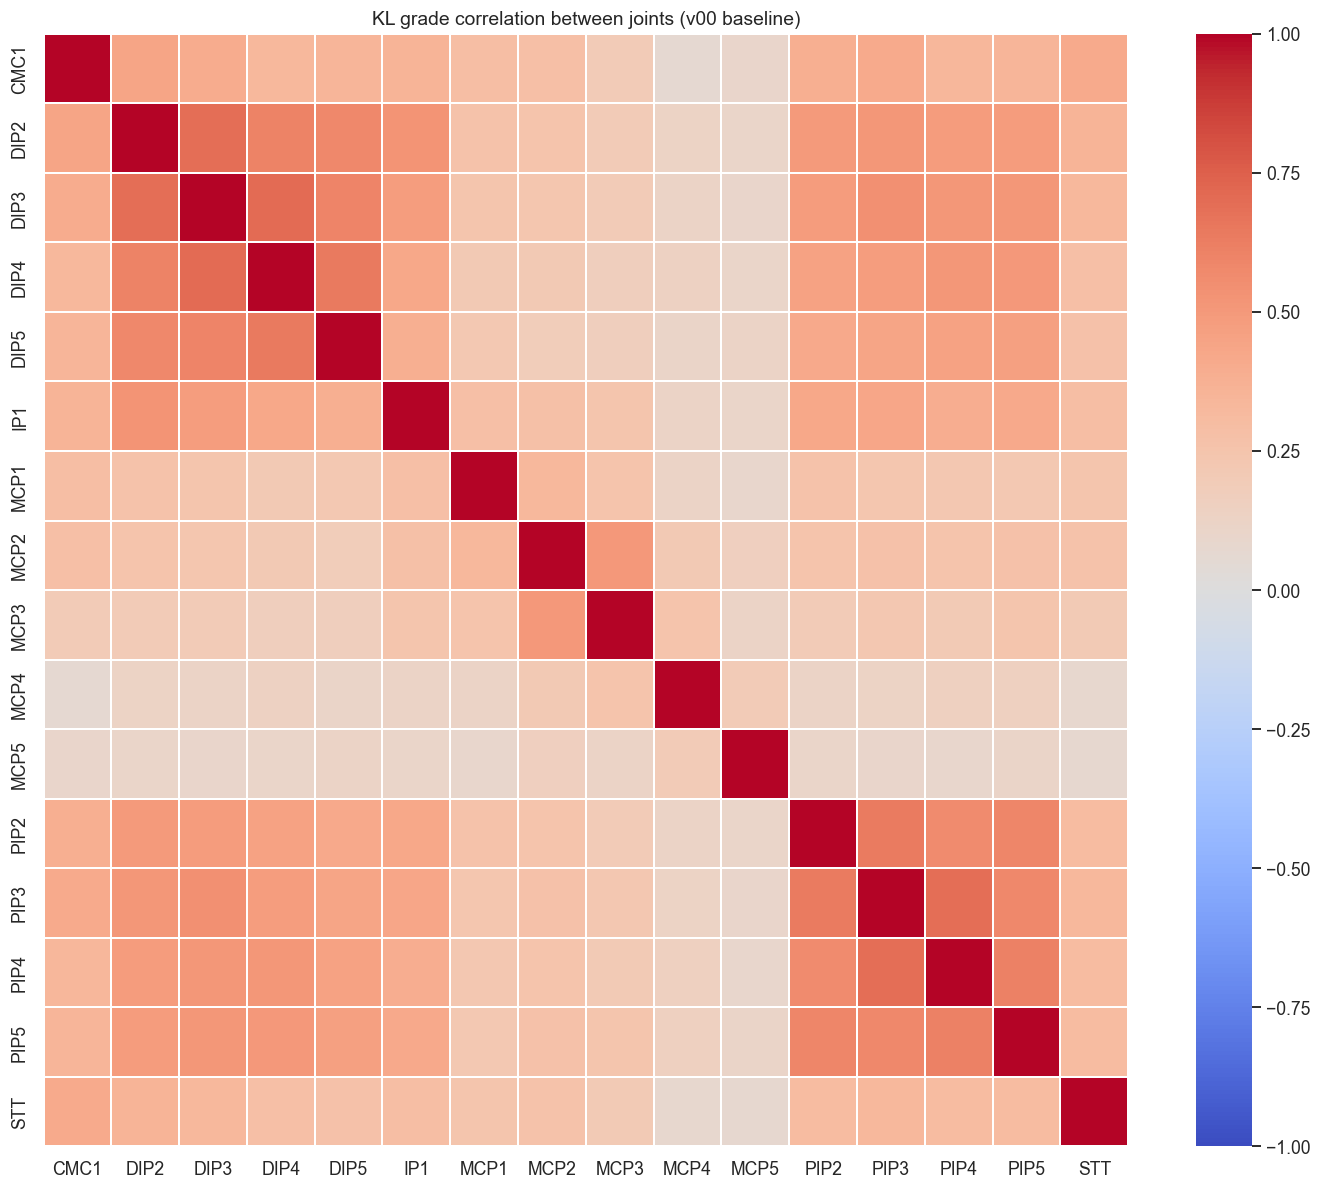

In [19]:
# Joint-level KL correlation matrix (v00)
kl_corr = kl_v00.corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(kl_corr, ax=ax, annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.3)
ax.set_title('KL grade correlation between joints (v00 baseline)')
plt.tight_layout()
plt.show()

## 11 · Multi-score profile per joint (radar / spider chart)

In [20]:
# For each joint compute mean of each score type at v00
profile_rows = []
for j in kl_joints:
    row = {'joint': j}
    for st in SCORE_TYPES:
        c = f'v00{j}_{st}'
        row[st] = df[c].mean() if c in df.columns else np.nan
    profile_rows.append(row)

profile = pd.DataFrame(profile_rows).set_index('joint').dropna(how='all')
print(profile.round(3))

          KL     OP    JSN     PW     ER     ME     CY
joint                                                 
CMC1   0.879  0.539  0.378  0.000  0.002  0.001  0.073
DIP2   0.894  0.558  0.433  0.002  0.034  0.001  0.086
DIP3   0.696  0.407  0.396  0.001  0.026  0.004  0.118
DIP4   0.532  0.236  0.388  0.001  0.018  0.001  0.073
DIP5   0.849  0.489  0.572  0.002  0.038  0.002  0.101
IP1    0.729  0.484  0.127  0.000  0.001  0.000  0.015
MCP1   0.413  0.237  0.168  0.000  0.000  0.003  0.019
MCP2   0.198  0.153  0.080  0.000  0.001  0.003  0.014
MCP3   0.185  0.169  0.087  0.000  0.000  0.001  0.026
MCP4   0.026  0.037  0.021  0.000  0.000  0.001  0.006
MCP5   0.016  0.027  0.018  0.000  0.000  0.004  0.007
PIP2   0.387  0.232  0.197  0.000  0.003  0.001  0.042
PIP3   0.541  0.279  0.280  0.001  0.004  0.001  0.061
PIP4   0.565  0.199  0.269  0.000  0.004  0.002  0.040
PIP5   0.450  0.261  0.232  0.000  0.004  0.000  0.044
STT    0.706  0.111  0.410  0.001  0.003  0.004  0.017


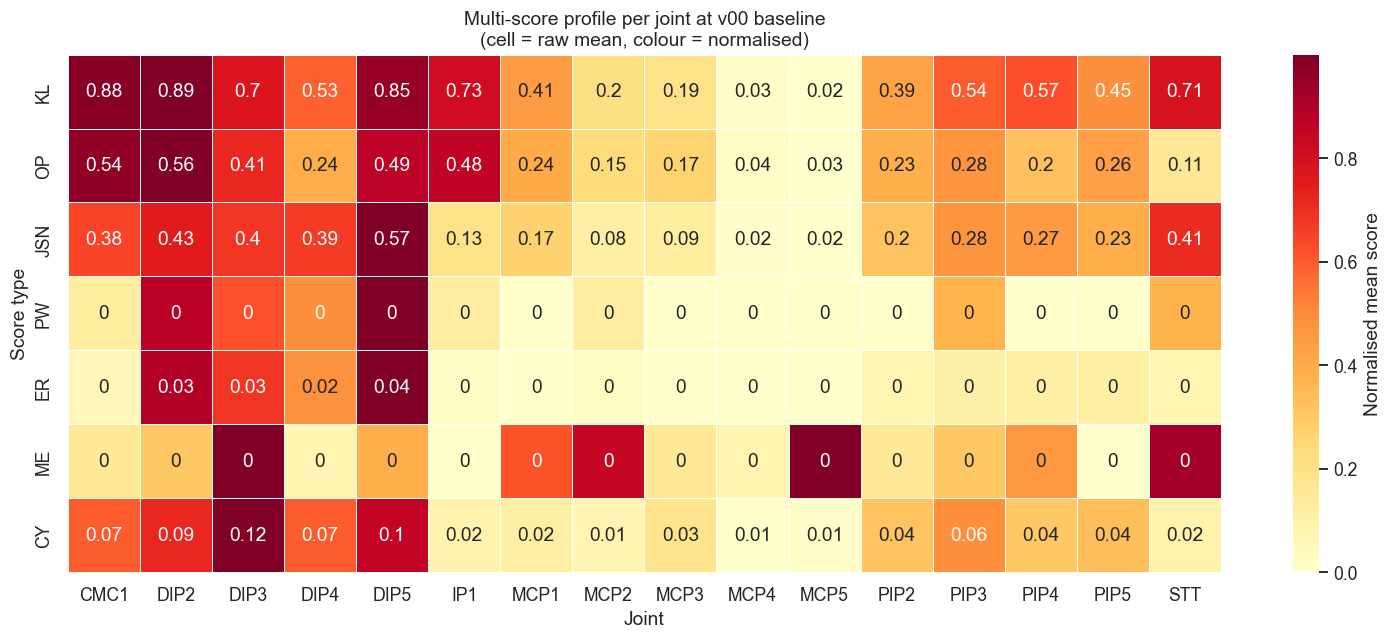

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)
sns.heatmap(profile_norm.T, ax=ax, annot=profile.T.round(2), fmt='g',
            cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Normalised mean score'})
ax.set_title('Multi-score profile per joint at v00 baseline\n(cell = raw mean, colour = normalised)')
ax.set_xlabel('Joint')
ax.set_ylabel('Score type')
plt.tight_layout()
plt.show()

## 12 · Pairwise scatter of most correlated score types

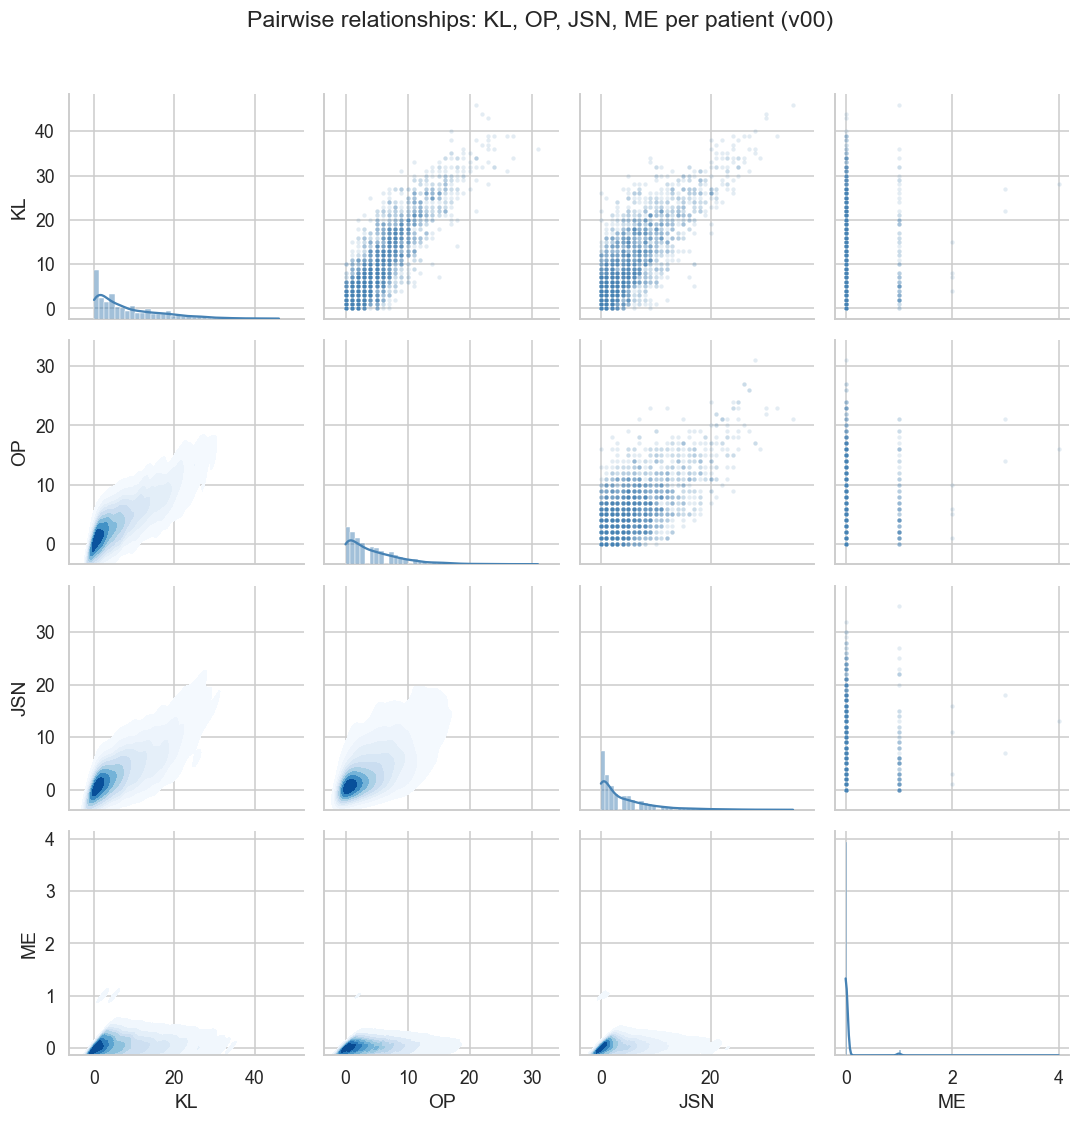

In [22]:
g = sns.PairGrid(sum_df[['KL', 'OP', 'JSN', 'ME']], height=2.5)
g.map_upper(sns.scatterplot, alpha=0.15, s=8, color='steelblue')
g.map_lower(sns.kdeplot, fill=True, cmap='Blues')
g.map_diag(sns.histplot, kde=True, color='steelblue')
g.figure.suptitle('Pairwise relationships: KL, OP, JSN, ME per patient (v00)', y=1.02)
plt.tight_layout()
plt.show()

## 13 · Patients with severe osteoarthritis (KL ≥ 3)

C:\Users\shinu\AppData\Local\Temp\ipykernel_17188\2075988079.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['n_severe_joints_v00'] = (df[kl_v00_cols_full] >= 3).sum(axis=1)
C:\Users\shinu\AppData\Local\Temp\ipykernel_17188\2075988079.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['n_severe_joints_v06'] = (df[kl_v06_cols_full] >= 3).sum(axis=1)


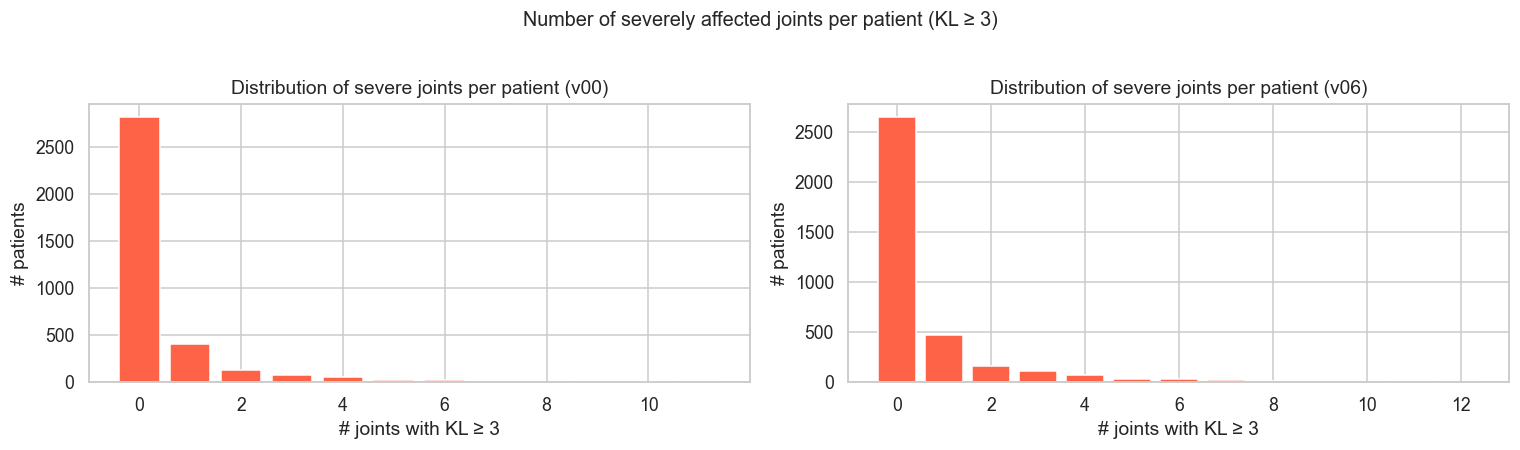

Patients with ≥1 severe joint at v00: 21.3%
Patients with ≥1 severe joint at v06: 26.1%


In [23]:
# Count joints with KL >= 3 per patient
df['n_severe_joints_v00'] = (df[kl_v00_cols_full] >= 3).sum(axis=1)
df['n_severe_joints_v06'] = (df[kl_v06_cols_full] >= 3).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, visit in zip(axes, ['n_severe_joints_v00', 'n_severe_joints_v06'], ['v00', 'v06']):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color='tomato', edgecolor='white')
    ax.set_xlabel('# joints with KL ≥ 3')
    ax.set_ylabel('# patients')
    ax.set_title(f'Distribution of severe joints per patient ({visit})')

plt.suptitle('Number of severely affected joints per patient (KL ≥ 3)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

pct_any_severe_v00 = (df['n_severe_joints_v00'] > 0).mean() * 100
pct_any_severe_v06 = (df['n_severe_joints_v06'] > 0).mean() * 100
print(f'Patients with ≥1 severe joint at v00: {pct_any_severe_v00:.1f}%')
print(f'Patients with ≥1 severe joint at v06: {pct_any_severe_v06:.1f}%')

## 14 · Image dataset analysis (Finger Joints.zip)

In [24]:
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    all_files = [f for f in z.namelist() if f.endswith('.png')]

img_pat = re.compile(r'Finger Joints/(\d+)_(\w+)\.png')
img_meta_rows = []
for f in all_files:
    m = img_pat.match(f)
    if m:
        img_meta_rows.append({'path': f, 'patient_id': m.group(1), 'joint': m.group(2)})

img_meta = pd.DataFrame(img_meta_rows)
print(f'Total images : {len(img_meta):,}')
print(f'Unique patients: {img_meta["patient_id"].nunique():,}')
print(f'Joint types : {sorted(img_meta["joint"].unique())}')
img_meta.head()

Total images : 41,060
Unique patients: 3,556
Joint types : ['dip2', 'dip3', 'dip4', 'dip5', 'mcp2', 'mcp3', 'mcp4', 'mcp5', 'pip2', 'pip3', 'pip4', 'pip5']


,path,patient_id,joint
0,Finger Joints/9000099_dip2.png,9000099,dip2
1,Finger Joints/9000099_dip3.png,9000099,dip3
2,Finger Joints/9000099_dip4.png,9000099,dip4
3,Finger Joints/9000099_dip5.png,9000099,dip5
4,Finger Joints/9000099_mcp2.png,9000099,mcp2


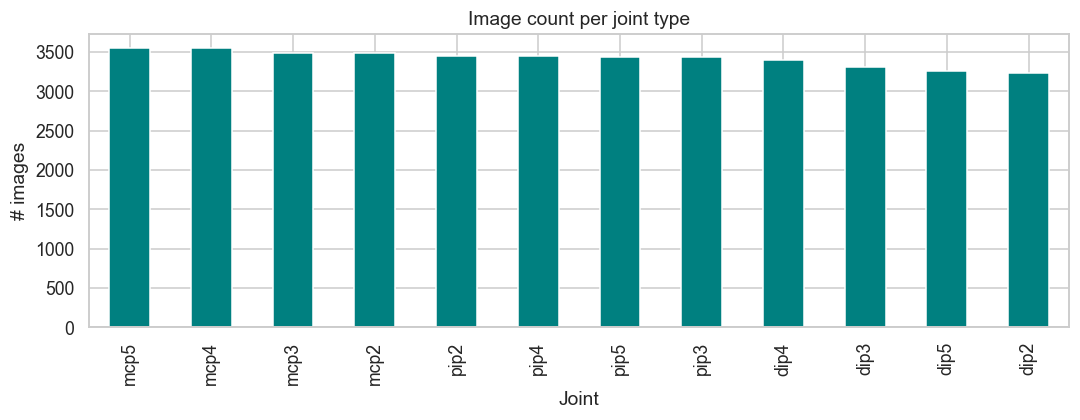

In [25]:
# Images per joint type
fig, ax = plt.subplots(figsize=(10, 4))
img_meta['joint'].value_counts().sort_values(ascending=False).plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Image count per joint type')
ax.set_xlabel('Joint')
ax.set_ylabel('# images')
plt.tight_layout()
plt.show()

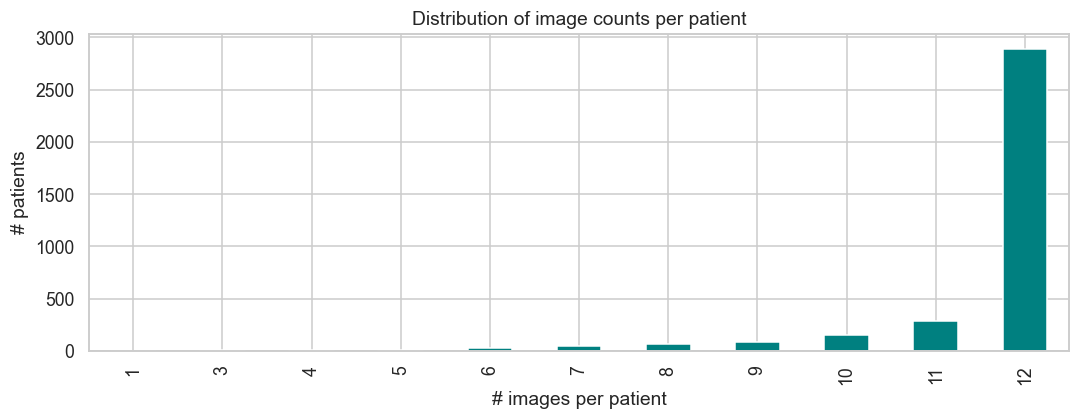

count    3556.000000
mean       11.546682
std         1.214684
min         1.000000
25%        12.000000
50%        12.000000
75%        12.000000
max        12.000000
dtype: float64


In [26]:
# Images per patient distribution
imgs_per_pt = img_meta.groupby('patient_id').size()
fig, ax = plt.subplots(figsize=(10, 4))
imgs_per_pt.value_counts().sort_index().plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Distribution of image counts per patient')
ax.set_xlabel('# images per patient')
ax.set_ylabel('# patients')
plt.tight_layout()
plt.show()

print(imgs_per_pt.describe())

In xlsx & images : 2
Only in xlsx     : 3,586
Only in images   : 3,554


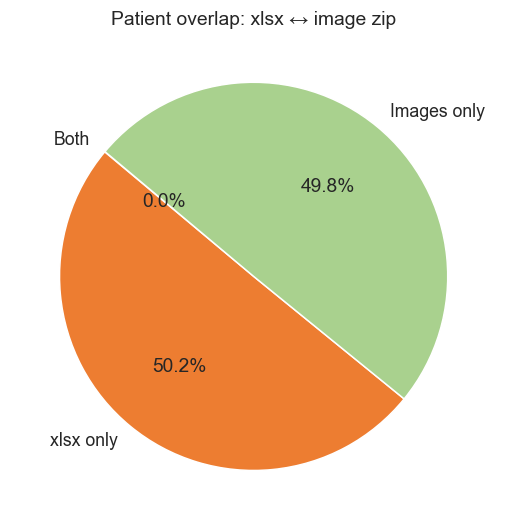

In [27]:
# Coverage: which patients in the xlsx have images?
xlsx_ids = set(df['duryeaid'].astype(str))
img_ids  = set(img_meta['patient_id'])

both   = xlsx_ids & img_ids
only_xlsx = xlsx_ids - img_ids
only_img  = img_ids  - xlsx_ids

print(f'In xlsx & images : {len(both):,}')
print(f'Only in xlsx     : {len(only_xlsx):,}')
print(f'Only in images   : {len(only_img):,}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([len(both), len(only_xlsx), len(only_img)],
       labels=['Both', 'xlsx only', 'Images only'],
       autopct='%1.1f%%', startangle=140,
       colors=['#5B9BD5', '#ED7D31', '#A9D18E'])
ax.set_title('Patient overlap: xlsx ↔ image zip')
plt.tight_layout()
plt.show()

## 15 · Sample images by joint type

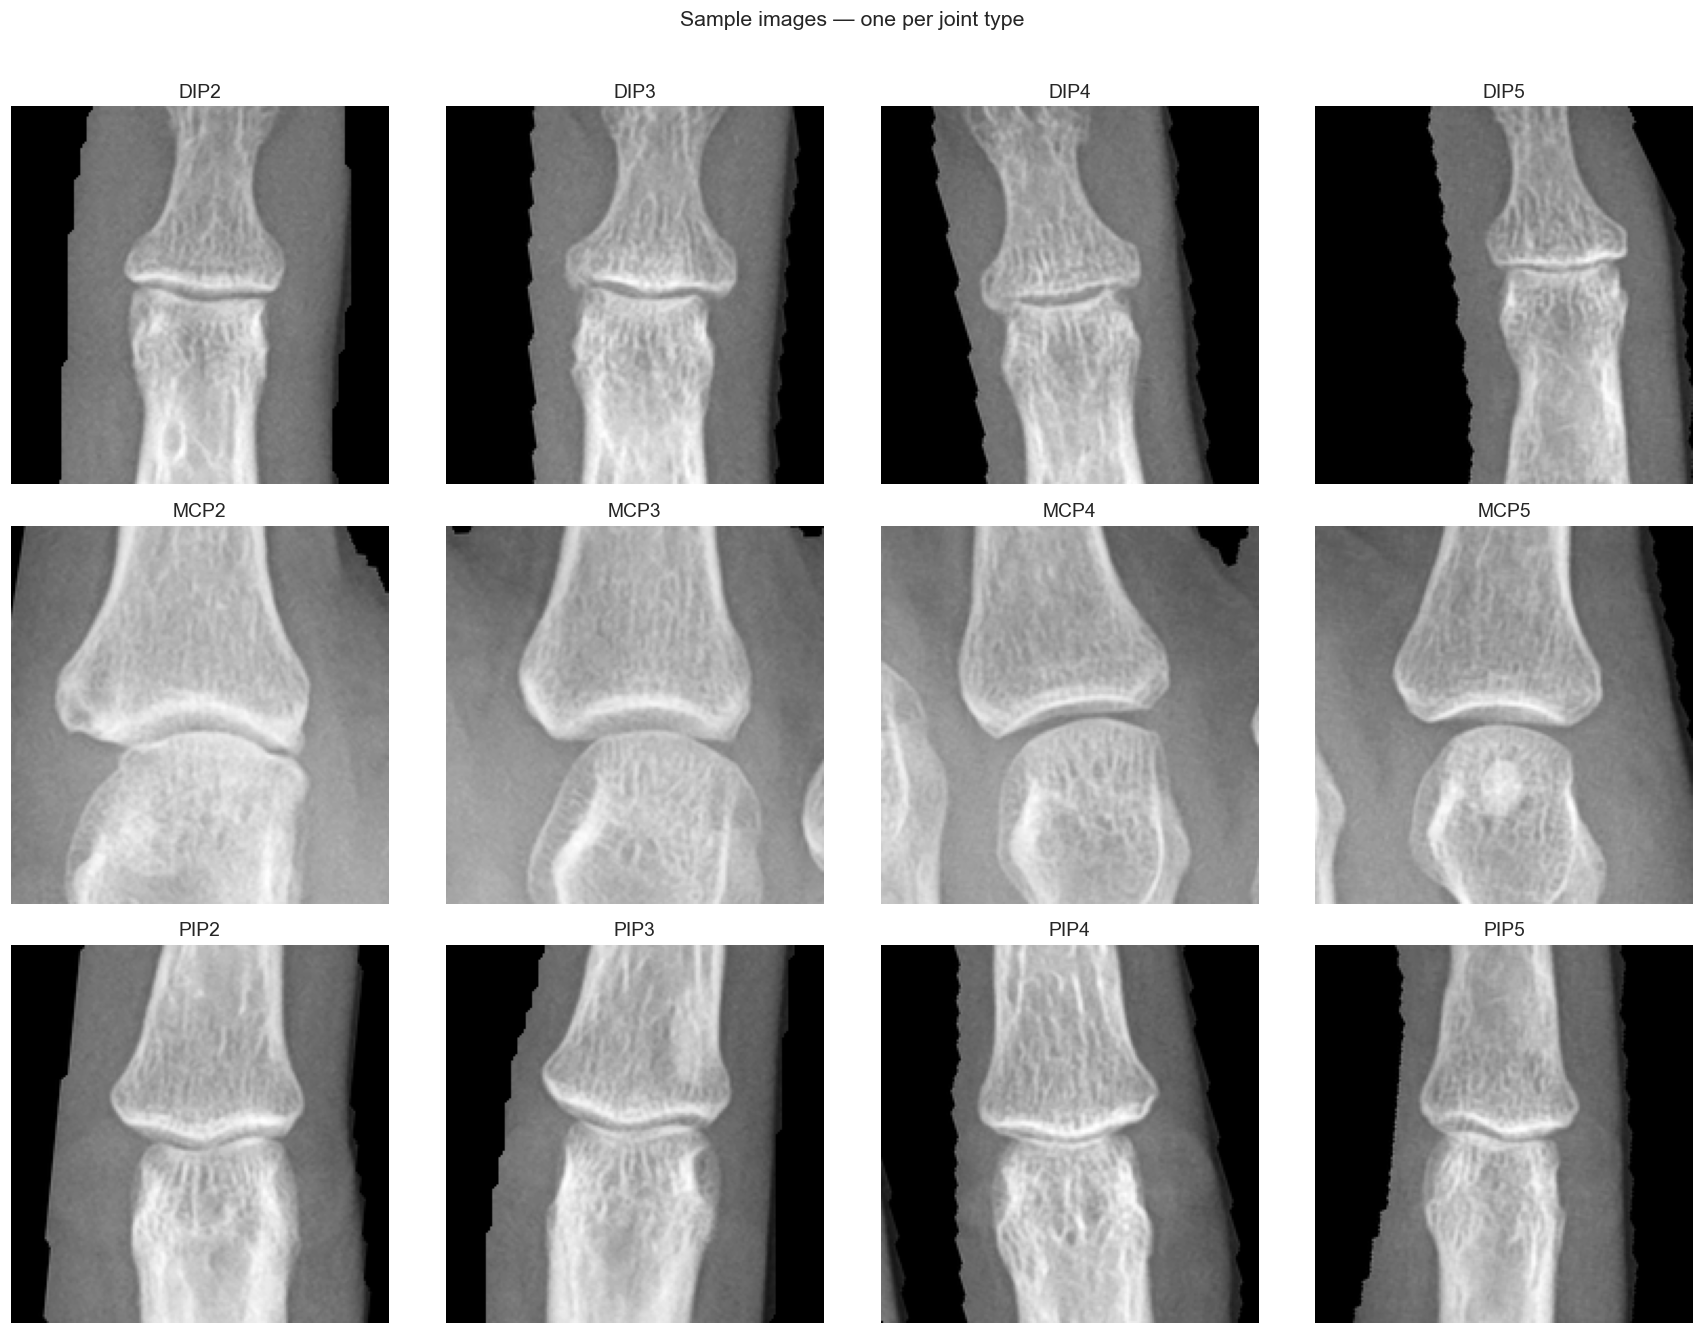

In [28]:
JOINT_TYPES = sorted(img_meta['joint'].unique())
n_joints = len(JOINT_TYPES)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    for ax, jt in zip(axes, JOINT_TYPES):
        sample_path = img_meta[img_meta['joint'] == jt].iloc[0]['path']
        with z.open(sample_path) as f:
            img = Image.open(BytesIO(f.read()))
        ax.imshow(img, cmap='gray')
        ax.set_title(jt.upper())
        ax.axis('off')

for ax in axes[n_joints:]:
    ax.set_visible(False)

plt.suptitle('Sample images — one per joint type', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 16 · Image properties (size, aspect ratio)

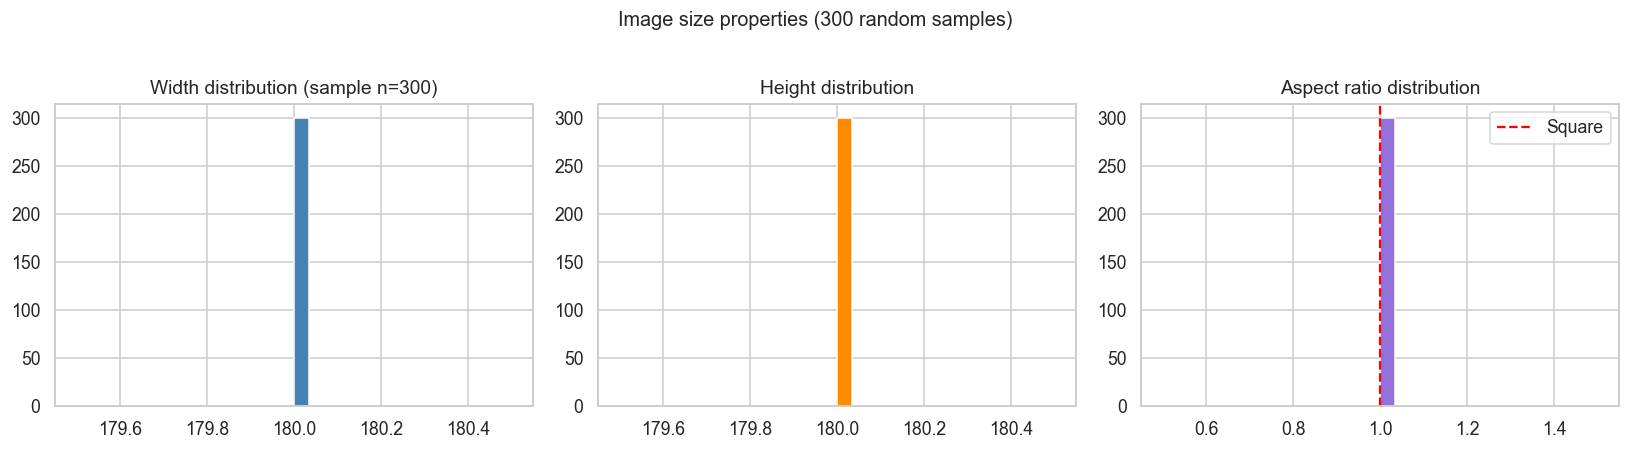

       width  height  aspect
count  300.0   300.0   300.0
mean   180.0   180.0     1.0
std      0.0     0.0     0.0
min    180.0   180.0     1.0
25%    180.0   180.0     1.0
50%    180.0   180.0     1.0
75%    180.0   180.0     1.0
max    180.0   180.0     1.0


In [29]:
# Sample 300 images to measure size distribution
np.random.seed(42)
sample_paths = img_meta.sample(300, random_state=42)['path'].tolist()

widths, heights = [], []
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    for p in sample_paths:
        with z.open(p) as f:
            img = Image.open(BytesIO(f.read()))
            widths.append(img.width)
            heights.append(img.height)

size_df = pd.DataFrame({'width': widths, 'height': heights})
size_df['aspect'] = size_df['width'] / size_df['height']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(size_df['width'],  bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Width distribution (sample n=300)')
axes[1].hist(size_df['height'], bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Height distribution')
axes[2].hist(size_df['aspect'], bins=30, color='mediumpurple', edgecolor='white')
axes[2].axvline(1.0, color='red', linestyle='--', label='Square')
axes[2].set_title('Aspect ratio distribution')
axes[2].legend()

plt.suptitle('Image size properties (300 random samples)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(size_df.describe().round(1))

## 17 · KL-stratified image sample

kl
0    1
Name: count, dtype: int64


TypeError: 'Axes' object is not subscriptable

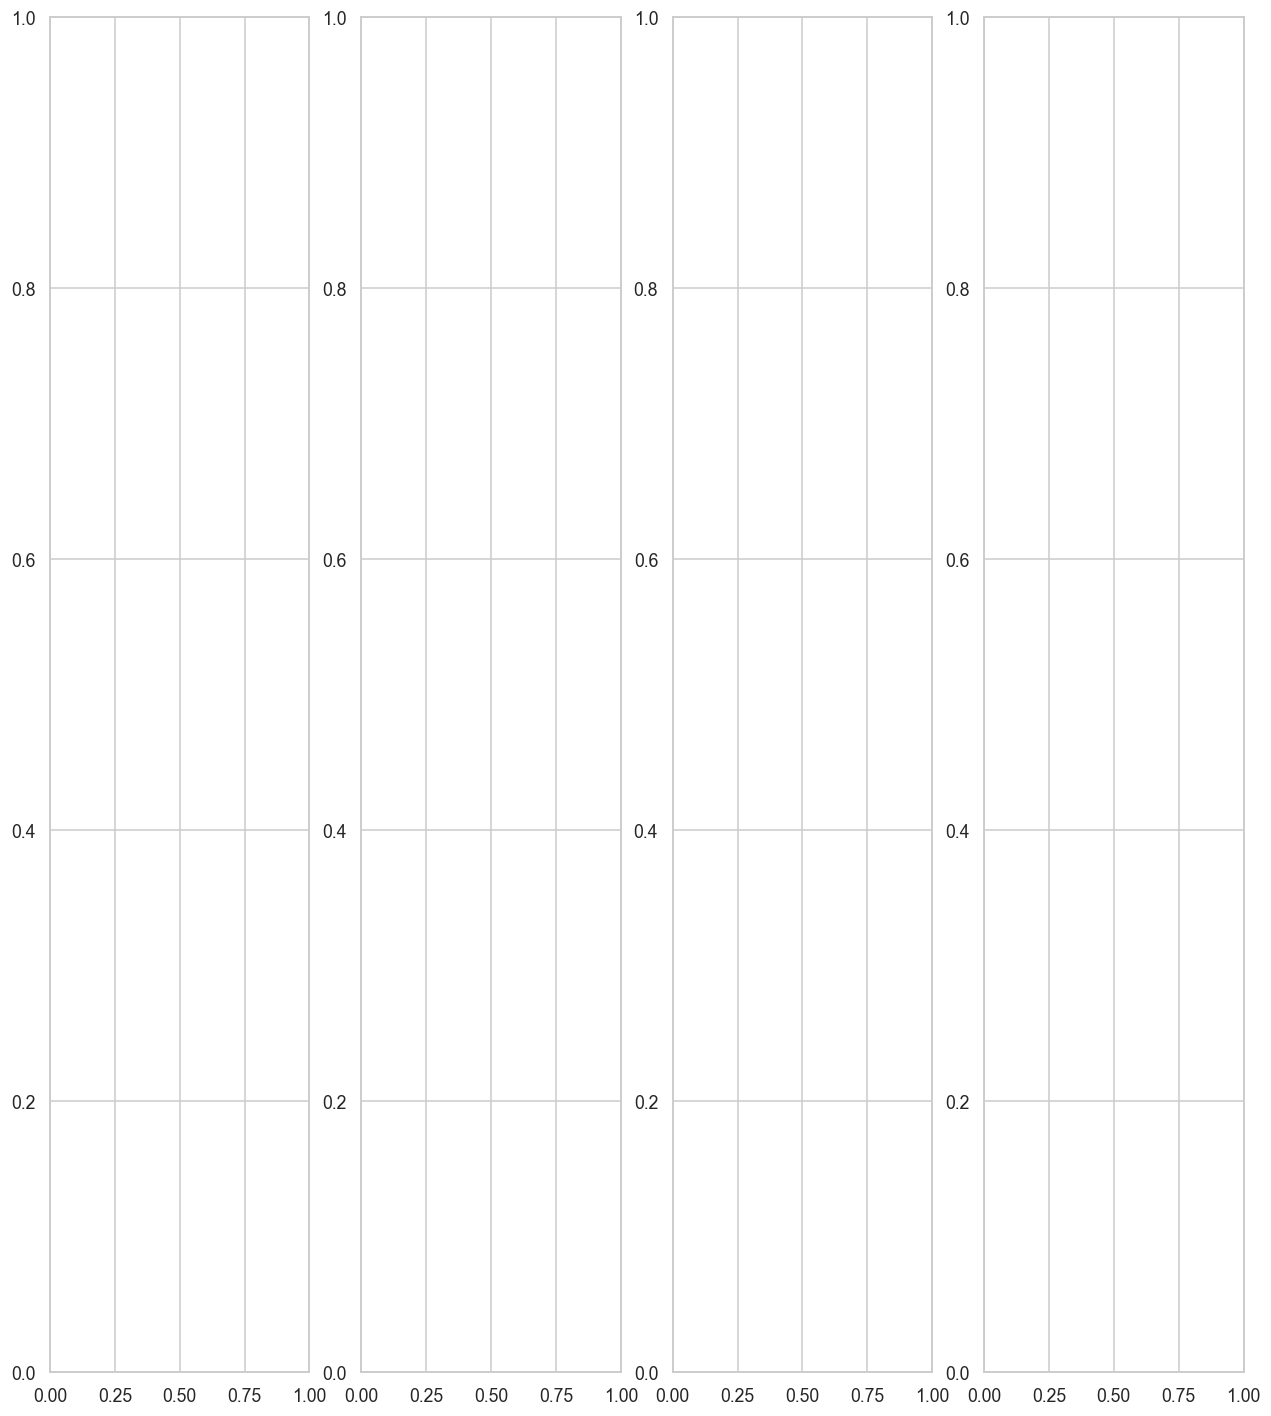

In [30]:
# Link images to KL labels for DIP2 (most common joint in images)
joint_name = 'dip2'
kl_col     = 'v00DIP2_KL'

linked = df[['duryeaid', kl_col]].dropna().copy()
linked['patient_id'] = linked['duryeaid'].astype(str)
linked = linked.rename(columns={kl_col: 'kl'})
linked['kl'] = linked['kl'].astype(int)

img_dip2 = img_meta[img_meta['joint'] == joint_name].copy()
img_dip2 = img_dip2.merge(linked[['patient_id', 'kl']], on='patient_id')
print(img_dip2['kl'].value_counts().sort_index())

fig, axes = plt.subplots(len(img_dip2['kl'].unique()), 4, figsize=(14, 16))

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    for row_idx, kl_grade in enumerate(sorted(img_dip2['kl'].unique())):
        samples = img_dip2[img_dip2['kl'] == kl_grade].sample(min(4, len(img_dip2[img_dip2['kl'] == kl_grade])), random_state=row_idx)
        for col_idx, (_, row) in enumerate(samples.iterrows()):
            with z.open(row['path']) as f:
                img = Image.open(BytesIO(f.read()))
            ax = axes[row_idx][col_idx]
            ax.imshow(img, cmap='gray')
            ax.set_title(f'KL={kl_grade}', fontsize=9)
            ax.axis('off')
        for col_idx in range(len(samples), 4):
            axes[row_idx][col_idx].set_visible(False)

plt.suptitle(f'DIP2 images stratified by KL grade (v00)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 18 · Image pixel intensity analysis by KL grade

In [ ]:
# Sample 50 images per KL grade for DIP2 and compare mean pixel intensity
intensity_rows = []
np.random.seed(0)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    for kl_grade in sorted(img_dip2['kl'].unique()):
        subset = img_dip2[img_dip2['kl'] == kl_grade].sample(min(50, len(img_dip2[img_dip2['kl'] == kl_grade])), random_state=0)
        for _, row in subset.iterrows():
            with z.open(row['path']) as f:
                img = Image.open(BytesIO(f.read())).convert('L')  # grayscale
                arr = np.array(img)
                intensity_rows.append({
                    'kl': kl_grade,
                    'mean_intensity': arr.mean(),
                    'std_intensity':  arr.std(),
                    'min_intensity':  arr.min(),
                    'max_intensity':  arr.max()
                })

int_df = pd.DataFrame(intensity_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=int_df, x='kl', y='mean_intensity', ax=axes[0], palette='RdYlGn_r')
axes[0].set_title('Mean pixel intensity by KL grade (DIP2)')
axes[0].set_xlabel('KL grade')

sns.boxplot(data=int_df, x='kl', y='std_intensity', ax=axes[1], palette='RdYlGn_r')
axes[1].set_title('Pixel intensity std by KL grade (DIP2)')
axes[1].set_xlabel('KL grade')

plt.suptitle('Pixel intensity statistics by KL grade (DIP2, n≤50 per grade)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 19 · Summary table

In [ ]:
summary = {
    'Metric': [
        'Total patients (xlsx)',
        'Score columns',
        'Visit timepoints',
        'Joint types (scored)',
        'Score types',
        'Hand — Right / Left (%)',
        'Total images (zip)',
        'Patients with images',
        'Image joint types',
        'Patients with ≥1 severe joint KL≥3 (v00)',
        'Patients with ≥1 severe joint KL≥3 (v06)',
        'Mean total KL burden v00 (±SD)',
        'Mean total KL burden v06 (±SD)',
    ],
    'Value': [
        f"{len(df):,}",
        len(meta),
        ', '.join(VISITS),
        len(kl_joints),
        ', '.join(SCORE_TYPES),
        f"{(df['Hand']==0).mean()*100:.1f}% / {(df['Hand']==1).mean()*100:.1f}%",
        f"{len(img_meta):,}",
        f"{img_meta['patient_id'].nunique():,}",
        ', '.join(JOINT_TYPES),
        f"{pct_any_severe_v00:.1f}%",
        f"{pct_any_severe_v06:.1f}%",
        f"{df['kl_sum_v00'].mean():.1f} ± {df['kl_sum_v00'].std():.1f}",
        f"{df['kl_sum_v06'].mean():.1f} ± {df['kl_sum_v06'].std():.1f}",
    ]
}

pd.DataFrame(summary).set_index('Metric')